In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv(r"../../data/o1_iptm_scoring/20260410_112451_af:model_2_multimer_v3_clip:False_nrecycle:4/ipTM_data.csv", header=0, index_col=0)
#mask = (df["KD (nM)"]<2000)
#mask = mask.fillna(True)
#df = df.loc[mask]
df = df.fillna(df["KD (nM)"].max())
#df = df[~df.index.isna()]
df = df.convert_dtypes(
    {c: float if c in ["ipTM", "default_iptm", "ab_iptm", "KD (nM)"] else str
     for c in df.columns}
)

In [ ]:
#df = df.loc[df["scaffold"]!="HER2"]
df

,scaffold,ipTM,default_iptm,ab_iptm,HCDR1,HCDR2,HCDR3,KD (nM),Binder
0,IL36R,0.656096,0.739505,0.572687,GYSFTSSW,INPGNVRT,TVVFYGEPYFPY,0.964376,True
0,IL36R,0.568203,0.652771,0.483635,GYSFTSSW,INPGNVRT,ARAVAGEWYFDY,422.65,False
0,IL36R,0.648694,0.730933,0.566455,GYSFTSSW,INPGNVRT,AKENNRYRFFDD,422.65,False
0,IL36R,0.669628,0.751299,0.587958,GYSFTSSW,INPGNVRT,ARVYSYGVPFDY,422.65,False
0,IL36R,0.636132,0.721319,0.550944,GYSFTSSW,INPGNVRT,HEDPYGMESLRY,422.65,False
0,C5,0.593689,0.724534,0.462845,GYIFSNYW,ILPGSGST,ARYFFGSSPNWYFDV,0.268904,True
0,C5,0.616174,0.744983,0.487364,GYIFSNYW,ILPGSGST,AKDRLSRGVGELYDS,422.65,False
0,C5,0.548083,0.682685,0.413481,GYIFSNYW,ILPGSGST,ARDLVYTGSYYGMDV,422.65,False
0,C5,0.630981,0.757333,0.50463,GYIFSNYW,ILPGSGST,ARGPMALLYYRGFDY,422.65,False
0,C5,0.459586,0.593122,0.32605,GYIFSNYW,ILPGSGST,AQGGWGLTQPISVDY,422.65,False


<Axes: xlabel='ipTM', ylabel='KD (nM)'>

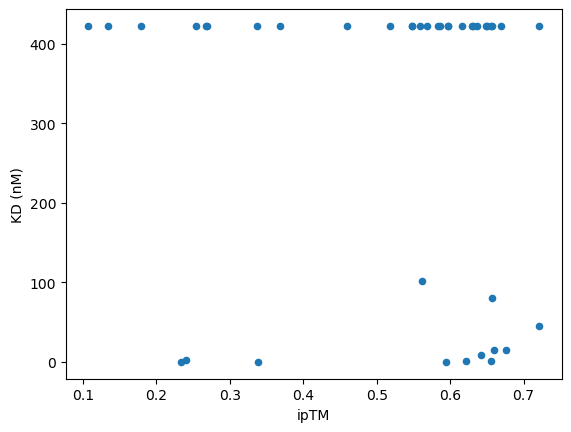

In [ ]:
df.plot("ipTM", "KD (nM)", kind="scatter")

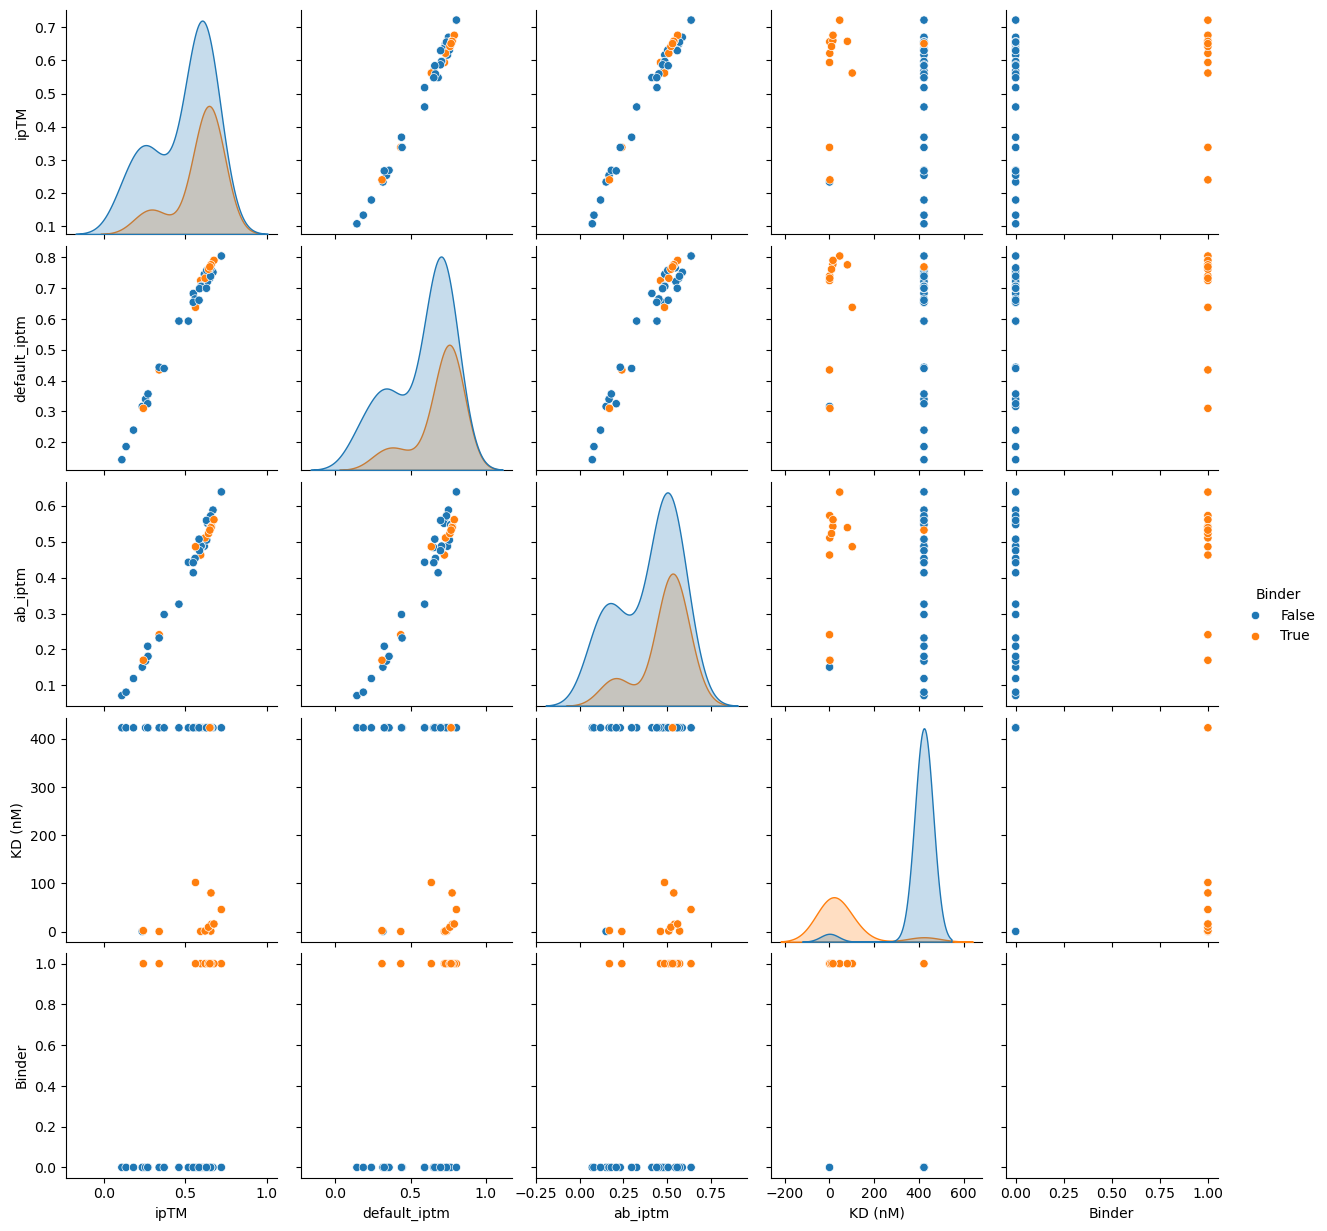

In [ ]:
sns.pairplot(df,
    hue="Binder",
    vars=[c for c in df.columns if "KD" in c or "Binder"==c or "iptm" in c.lower()],
    dropna=True,
    )

<Axes: xlabel='scaffold', ylabel='ipTM'>

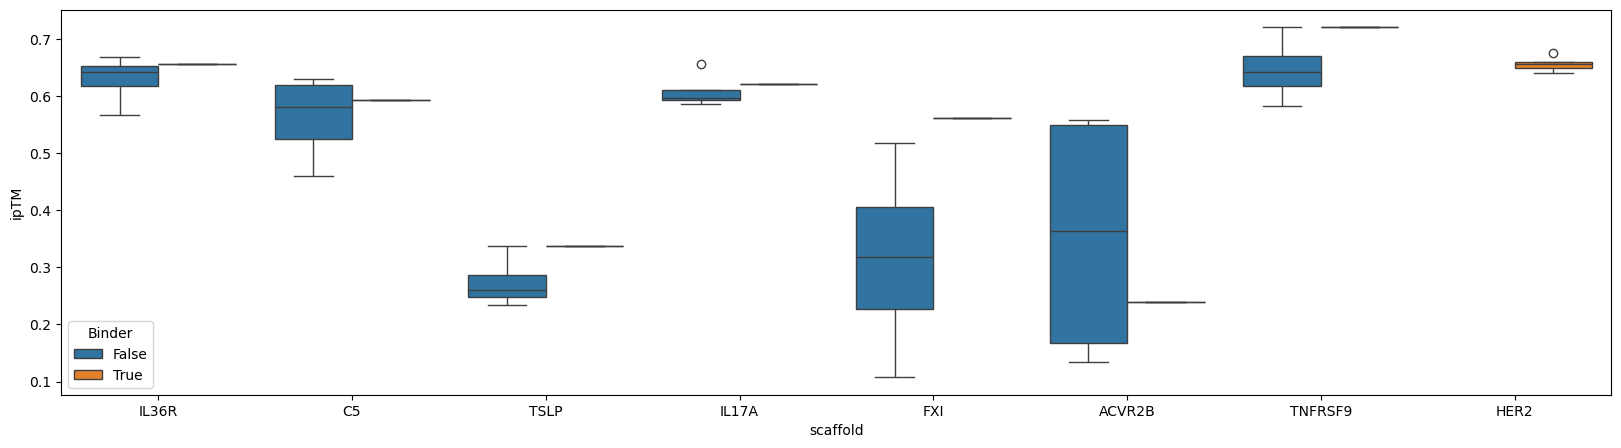

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,5))
sns.boxplot(
    df,
    x = "scaffold",
    y = "ipTM",
    hue = "Binder",
    #inner = "point",
    #width = 1,
    ax = ax
)

In [ ]:
df = pd.read_csv("/home/hgf_dkfz/hgf_dsb0249/workspaces/haicwork/hgf_dsb0249-BinderDesign/flexcraft/data/o1_iptm_scoring/20260410_112045_fig13_af:model_2_multimer_v3_clip:False_nrecycle:0/ipTM_data.csv", index_col=0)
df

,scaffold,ipTM,default_iptm,ab_iptm
0,7PA9,0.328881,0.389817,0.267945
0,7Q6C,0.724430,0.807467,0.641393
0,7REW,0.559673,0.684521,0.434826
0,7SEG,0.577308,0.675874,0.478743
0,7UVF,0.762566,0.856006,0.669126
0,7UXL,0.388315,0.470386,0.306244
0,7VGS,0.683964,0.764280,0.603648
0,8G3P,0.327364,0.372148,0.282579
0,8GKL,0.203368,0.279541,0.127195
0,8K0D,0.744834,0.788481,0.701188


In [ ]:
ctrl = pd.Series(
    [
        0.75,
        0.9,
        0.9,
        0.75,
        0.9,
        0.9,
        0.9,
        0.75,
        0.9,
        0.9,
        0.8,
        0.8,
        0.9,
        0.9,
        0.9
    ],
    index=df.scaffold)
df["ctrl"] = ctrl.values
df

,scaffold,ipTM,default_iptm,ab_iptm,ctrl
0,7PA9,0.328881,0.389817,0.267945,0.75
0,7Q6C,0.724430,0.807467,0.641393,0.90
0,7REW,0.559673,0.684521,0.434826,0.90
0,7SEG,0.577308,0.675874,0.478743,0.75
0,7UVF,0.762566,0.856006,0.669126,0.90
0,7UXL,0.388315,0.470386,0.306244,0.90
0,7VGS,0.683964,0.764280,0.603648,0.90
0,8G3P,0.327364,0.372148,0.282579,0.75
0,8GKL,0.203368,0.279541,0.127195,0.90
0,8K0D,0.744834,0.788481,0.701188,0.90


/hkfs/work/workspace_haic/scratch/hgf_dsb0249-BinderDesign/miniforge3/envs/plotting/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='ipTM', ylabel='ctrl'>

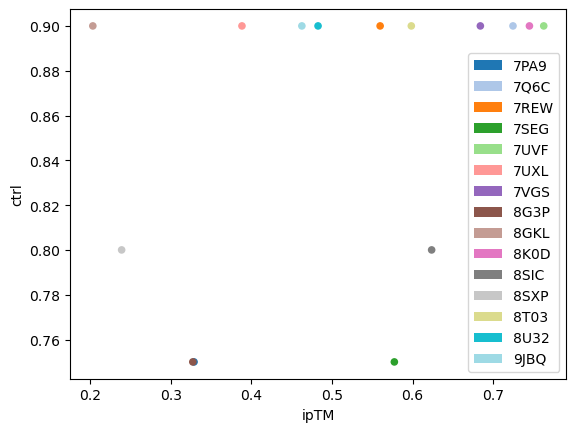

In [ ]:
df.plot("ipTM", "ctrl", kind="scatter", c="scaffold", cmap="tab20")

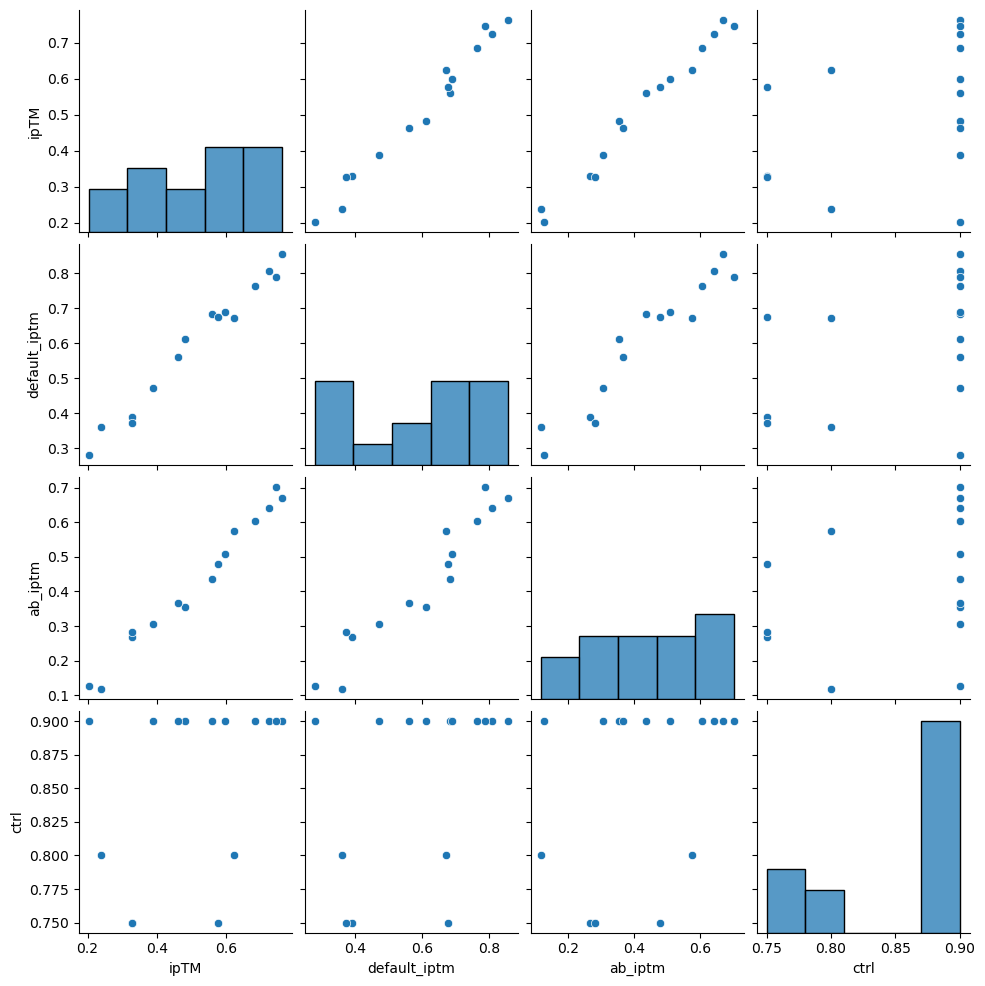

In [ ]:
sns.pairplot(df,
    )